In [244]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [245]:
df = pd.read_csv('HousingData.csv')

In [246]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [247]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [248]:
df.isna().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [249]:
df.shape

(506, 14)

In [250]:
df['AGE'] = df['AGE'].fillna(df['AGE'].mean())


In [251]:
df['AGE'].isna().sum()

np.int64(0)

In [252]:
med_col= ['CRIM','INDUS','CHAS','LSTAT']
df[med_col] = df[med_col].fillna(df[med_col].mean())

In [253]:
df.isna().sum()

,0
CRIM,0
ZN,20
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [254]:
df['ZN'] = df['ZN'].fillna(df['ZN'].mean())


In [255]:
df.shape

(506, 14)

In [256]:
df.duplicated().sum()

np.int64(0)

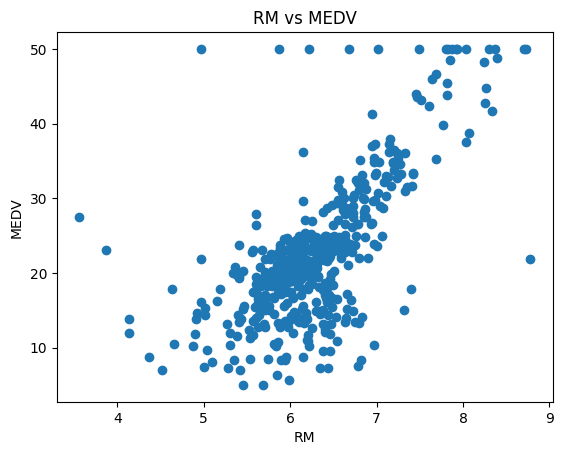

In [257]:
plt.scatter(df['RM'], df['MEDV'])
plt.xlabel('RM')
plt.ylabel('MEDV')
plt.title('RM vs MEDV')
plt.show()


In [258]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [259]:
model =knn = KNeighborsRegressor(n_neighbors=5)

model.fit(X_train, y_train)

KNeighborsRegressor()

In [260]:
y_pred = model.predict(X_test)
print("Prediction",y_pred)

Prediction [24.   29.34 14.64 28.12 16.74 33.2  19.66 16.76 17.22 21.18 23.38 23.36
 11.72 22.66 23.7  25.62 21.18 14.84 35.14 10.6  25.86 29.34 16.78 20.28
 18.88 22.52 22.46 10.28 23.38 21.92 22.68 23.44  9.86 24.9  17.54 21.12
 21.66 25.98 22.52 26.92 21.92 30.46 38.16 21.74 26.06 12.38 19.46 27.96
 19.8  21.56 22.44 31.38 17.96 21.92 30.36 21.38 11.5  35.14 21.74 21.68
 25.3  38.82 28.92 14.3  30.46 23.38 12.26 23.28 34.64 12.34 20.58 21.9
 17.66 25.68 22.46  8.98 19.72 38.16 10.7  14.4  24.86 15.96 24.32 11.22
 21.46 31.98 14.16 21.66 25.98 17.86 22.98 14.7  17.48 20.9  24.5  17.78
 22.32  8.7  10.76 11.92 21.8  22.46]


In [261]:
mae = mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error",mae)
r2_score = r2_score(y_test,y_pred)
print("R2 Score",r2_score)

Mean Absolute Error 3.849411764705883
R2 Score 0.595920446540199


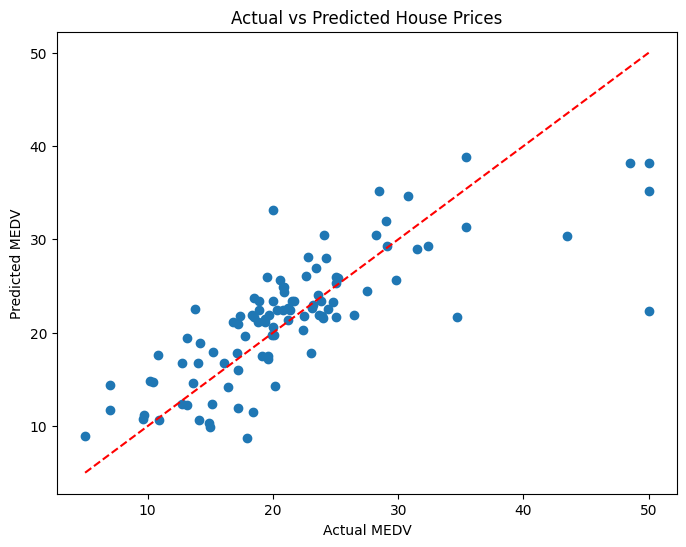

In [262]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

In [263]:
df.tail(1)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
505,0.04741,0.0,11.93,0.0,0.573,6.03,68.518519,2.505,1,273,21.0,396.9,7.88,11.9


In [264]:
model.predict([[0.04741,0.0,11.93,0.0,0.573,6.03,68.518519,2.505,1,273,21.0,396.9,7.88]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


array([21.02])

In [265]:
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

result['Difference'] = result['Actual'] - result['Predicted']

print(result.head(20))

     Actual  Predicted  Difference
173    23.6      24.00       -0.40
274    32.4      29.34        3.06
491    13.6      14.64       -1.04
72     22.8      28.12       -5.32
452    16.1      16.74       -0.64
76     20.0      33.20      -13.20
316    17.8      19.66       -1.86
140    14.0      16.76       -2.76
471    19.6      17.22        2.38
500    16.8      21.18       -4.38
218    21.5      23.38       -1.88
9      18.9      23.36       -4.46
414     7.0      11.72       -4.72
78     21.2      22.66       -1.46
323    18.5      23.70       -5.20
473    29.8      25.62        4.18
124    18.8      21.18       -2.38
388    10.2      14.84       -4.64
195    50.0      35.14       14.86
448    14.1      10.60        3.50


In [266]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train R2:", train_score)
print("Test R2:", test_score)

Train R2: 0.6405528202849868
Test R2: 0.595920446540199


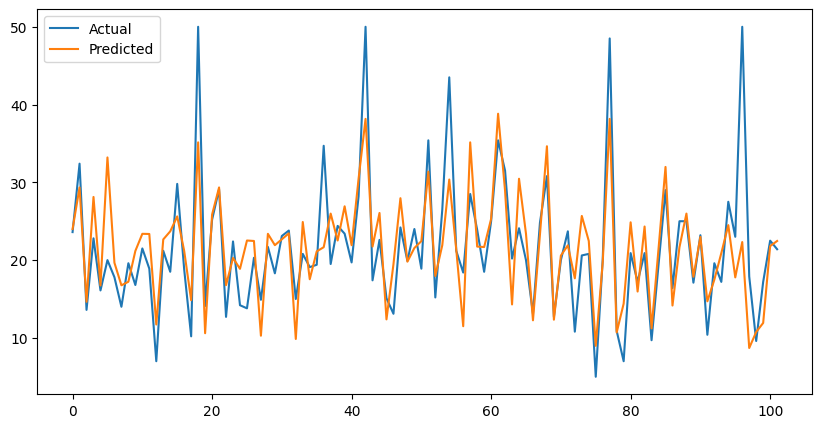

In [267]:
plt.figure(figsize=(10,5))
plt.plot(range(len(y_test)), y_test.values, label='Actual')
plt.plot(range(len(y_pred)), y_pred, label='Predicted')

plt.legend()
plt.show()